# 05 — Feature: CPU
Parses the `Cpu` string into structured features and applies target encoding.

**Output features:** `CPU_GHz`, `CPU_Brand_TE`, `CPU_Family_TE`, `CPU_TE`

In [1]:
!pip install category_encoders

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 12.4/12.4 MB 77.3 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 90.4 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 84.2 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------------- -------------------------- 12.8/37.3 MB 71.0 MB/s eta 0:00:01
   ---------------------- ----------------- 21.2/37.3 MB 56.1 MB/s eta 0:00:01
   ---------------------------- ----------- 27.0/37.3 MB 46.2 MB/s eta 0:00:01
   ------

In [3]:
!pip install pandas numpy matplotlib seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 79.7 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 70.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 86.8 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ------------------------------

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import category_encoders as ce

In [5]:
ld = pd.read_csv("laptop_data_features.csv")
print(f"Shape: {ld.shape}")

Shape: (1303, 23)


In [6]:
# Explore Cpu
print(ld['Cpu'].value_counts().head(15))
print(f"\nUnique CPUs: {ld['Cpu'].nunique()}")

Cpu
Intel Core i5 7200U 2.5GHz              190
Intel Core i7 7700HQ 2.8GHz             146
Intel Core i7 7500U 2.7GHz              134
Intel Core i7 8550U 1.8GHz               73
Intel Core i5 8250U 1.6GHz               72
Intel Core i5 6200U 2.3GHz               68
Intel Core i3 6006U 2GHz                 64
Intel Core i7 6500U 2.5GHz               49
Intel Core i7 6700HQ 2.6GHz              43
Intel Core i3 7100U 2.4GHz               37
Intel Core i5 7300HQ 2.5GHz              33
Intel Celeron Dual Core N3350 1.1GHz     30
Intel Celeron Dual Core N3060 1.6GHz     28
Intel Core i7 6600U 2.6GHz               18
Intel Core i3 6006U 2.0GHz               16
Name: count, dtype: int64

Unique CPUs: 118


In [7]:
# Parse CPU string into Brand, Family, GHz
def parse_cpu(cpu_str):
    if pd.isna(cpu_str):
        return pd.Series(['Unknown', 'Unknown', np.nan],
                         index=['CPU_Brand', 'CPU_Family', 'CPU_GHz'])
    tokens = cpu_str.split()
    brand  = tokens[0]                               # Intel, AMD, Samsung
    family = tokens[1] if len(tokens) > 1 else 'Unknown'  # Core, Celeron, A-Series
    ghz_match = re.search(r'(\d+\.?\d*)\s?GHz', cpu_str)
    ghz = float(ghz_match.group(1)) if ghz_match else np.nan
    return pd.Series([brand, family, ghz],
                     index=['CPU_Brand', 'CPU_Family', 'CPU_GHz'])

ld[['CPU_Brand', 'CPU_Family', 'CPU_GHz']] = ld['Cpu'].apply(parse_cpu)
print("Parse sample:")
print(ld[['Cpu', 'CPU_Brand', 'CPU_Family', 'CPU_GHz']].head(5).to_string())

Parse sample:
                          Cpu CPU_Brand CPU_Family  CPU_GHz
0        Intel Core i5 2.3GHz     Intel       Core      2.3
1        Intel Core i5 1.8GHz     Intel       Core      1.8
2  Intel Core i5 7200U 2.5GHz     Intel       Core      2.5
3        Intel Core i7 2.7GHz     Intel       Core      2.7
4        Intel Core i5 3.1GHz     Intel       Core      3.1


In [8]:
# Handle missing GHz
print(f"Missing CPU_GHz: {ld['CPU_GHz'].isnull().sum()}")
ld['CPU_GHz'].fillna(ld['CPU_GHz'].median(), inplace=True)

Missing CPU_GHz: 0


C:\Users\akshi\AppData\Local\Temp\ipykernel_25548\3287466897.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  ld['CPU_GHz'].fillna(ld['CPU_GHz'].median(), inplace=True)


0       2.3
1       1.8
2       2.5
3       2.7
4       3.1
       ... 
1298    2.5
1299    2.5
1300    1.6
1301    2.5
1302    1.6
Name: CPU_GHz, Length: 1303, dtype: float64

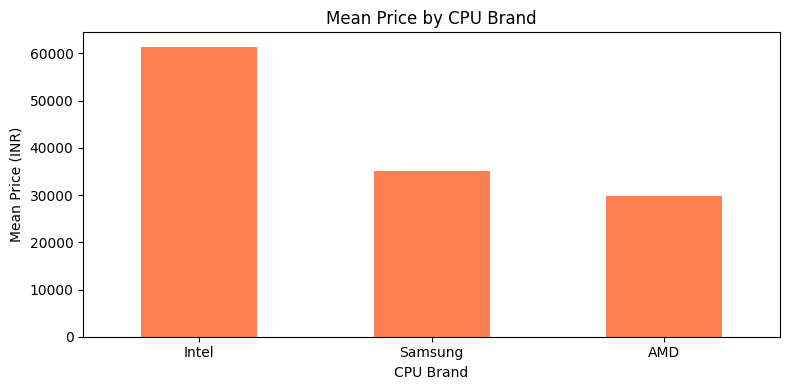

In [9]:
# Visualize Brand vs Price
plt.figure(figsize=(8, 4))
brand_mean = ld.groupby('CPU_Brand')['Price'].mean().sort_values(ascending=False)
brand_mean.plot(kind='bar', color='coral')
plt.title("Mean Price by CPU Brand")
plt.xlabel("CPU Brand")
plt.ylabel("Mean Price (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

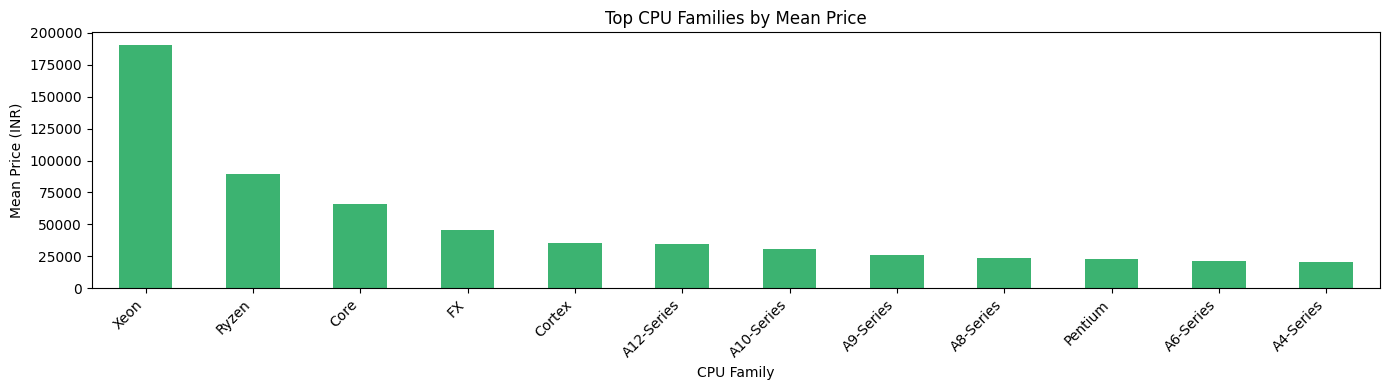

In [10]:
# Visualize top CPU Families vs Price
plt.figure(figsize=(14, 4))
family_mean = ld.groupby('CPU_Family')['Price'].mean().sort_values(ascending=False).head(12)
family_mean.plot(kind='bar', color='mediumseagreen')
plt.title("Top CPU Families by Mean Price")
plt.xlabel("CPU Family")
plt.ylabel("Mean Price (INR)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

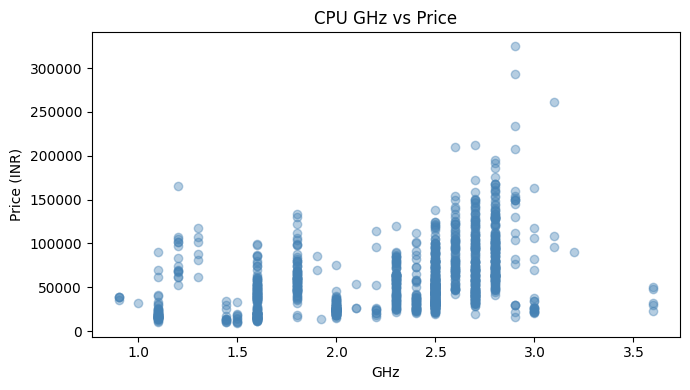

Correlation CPU_GHz vs Price: 0.4303


In [11]:
# CPU GHz vs Price scatter
plt.figure(figsize=(7, 4))
plt.scatter(ld['CPU_GHz'], ld['Price'], alpha=0.4, color='steelblue')
plt.title("CPU GHz vs Price")
plt.xlabel("GHz")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()
print(f"Correlation CPU_GHz vs Price: {ld['CPU_GHz'].corr(ld['Price']):.4f}")

In [12]:
# Target mean encode Brand
brand_mean = ld.groupby('CPU_Brand')['Price'].mean()
ld['CPU_Brand_TE'] = ld['CPU_Brand'].map(brand_mean)

# Target mean encode Family
family_mean = ld.groupby('CPU_Family')['Price'].mean()
ld['CPU_Family_TE'] = ld['CPU_Family'].map(family_mean)

In [13]:
# Target encode full CPU string (captures model-level detail)
encoder = ce.TargetEncoder(cols=['Cpu'])
ld['CPU_TE'] = encoder.fit_transform(ld[['Cpu']], ld['Price'])

In [14]:
# Correlation with Price
cpu_cols = ['CPU_GHz', 'CPU_Brand_TE', 'CPU_Family_TE', 'CPU_TE']
print("Correlation with Price:")
print(ld[cpu_cols + ['Price']].corr()['Price'].sort_values(ascending=False))

Correlation with Price:
Price            1.000000
CPU_TE           0.654484
CPU_Family_TE    0.477055
CPU_GHz          0.430293
CPU_Brand_TE     0.181168
Name: Price, dtype: float64


In [15]:
# Drop raw and intermediate string columns
ld.drop(columns=['Cpu', 'CPU_Brand', 'CPU_Family'], inplace=True)

In [16]:
ld.to_csv("laptop_data_features.csv", index=False)
print("Saved: laptop_data_features.csv")
print(f"Shape: {ld.shape}")
print(f"Columns: {list(ld.columns)}")

Saved: laptop_data_features.csv
Shape: (1303, 26)
Columns: ['Inches', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Company_TE', 'Type_2 in 1 Convertible', 'Type_Gaming', 'Type_Netbook', 'Type_Notebook', 'Type_Ultrabook', 'Type_Workstation', 'Screen_Width', 'Screen_Height', 'Screen_PPI', 'Screen_IsTouchscreen', 'Screen_IsIPS', 'Screen_IsRetina', 'Screen_IsFullHD', 'Screen_Is4K', 'CPU_GHz', 'CPU_Brand_TE', 'CPU_Family_TE', 'CPU_TE']
